In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

data_dir = Path("..") / "data" / "processed"  

X_train = np.load(data_dir / "X_train.npy")
y_train = np.load(data_dir / "y_train.npy")
X_val   = np.load(data_dir / "X_val.npy")
y_val   = np.load(data_dir / "y_val.npy")
X_test  = np.load(data_dir / "X_test.npy")
y_test  = np.load(data_dir / "y_test.npy")

print(f"X_train shape : {X_train.shape}")
print(f"y_train dist  : PASS={sum(y_train==0)}, FAIL={sum(y_train==1)}")



# Save model
model.save('ann_model.h5')
print("\nModel saved: ann_model.h5")

X_train shape : (2340, 195)
y_train dist  : PASS=1170, FAIL=1170

Model saved: ann_model.h5


In [28]:
def build_ann(input_dim):
  model=Sequential([

  #layer 1
  Dense(128,input_dim=input_dim),
  BatchNormalization(),
  Dropout(0.3),
  tf.keras.layers.Activation('relu'),

  #Layer-2
  Dense(128),
  tf.keras.layers.Activation('relu'),
  BatchNormalization(),
  Dropout(0.3),

  #Layer-3
  Dense(64),
  tf.keras.layers.Activation('relu'),
  BatchNormalization(),
  Dropout(0.2),

  #ouput
  Dense(1,activation='sigmoid')


  ])


  return model
model=build_ann(X_train.shape[1])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,201 (200.00 KB)

 Trainable params: 50,561 (197.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [29]:
#compile and train krna hai model to bnalia


neg=(y_train==0).sum()
pos=(y_train==1).sum()
class_weight={0:1.0,1:neg/pos} #vaise to iski zarurt nhi smote kra hua hai

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#callback or early stopping to avoid early stopping
callbacks=[
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]



history=model.fit(
    X_train,y_train,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6549 - loss: 0.6606 - val_accuracy: 0.4679 - val_loss: 0.7615
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7986 - loss: 0.4275 - val_accuracy: 0.8226 - val_loss: 0.4508
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8638 - loss: 0.3138 - val_accuracy: 0.9658 - val_loss: 0.2332
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9060 - loss: 0.2485 - val_accuracy: 0.9850 - val_loss: 0.1210
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9247 - loss: 0.2024 - val_accuracy: 0.9893 - val_loss: 0.0668
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9359 - loss: 0.1725 - val_accuracy: 0.9893 - val_loss: 0.0445
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9605 - loss: 0.1205 - val_accuracy: 0.9915 - val_loss: 0.0309
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9615 - loss: 0.1092 - val_accuracy: 0.9957 - 

In [30]:
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score # Added precision_recall_curve

#threshold tuning samjate hai

y_prob_ann=model.predict(X_test).flatten() # taki 1d array dede prob ki

p,r,t=precision_recall_curve(y_test,y_prob_ann)

f1=2*(p[:-1]*r[:-1])/(p[:-1]+r[:-1]+1e-8)

# ab mujhe best threshold niklna konse index pr aayega f1

best_t=t[np.argmax(f1)] #threshold ki value jiske liye f1 maximum hoga

y_pred_ann=(y_prob_ann>=best_t).astype(int)

print(f"{best_t:.3f}") # Corrected f-string
print(classification_report(y_test,y_pred=y_pred_ann, target_names=["PASS(0)","FAIL(1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ann):.4f}") # Corrected y_proba_ann to y_prob_ann

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
0.234
              precision    recall  f1-score   support

     PASS(0)       0.94      0.96      0.95       293
     FAIL(1)       0.24      0.19      0.21        21

    accuracy                           0.90       314
   macro avg       0.59      0.57      0.58       314
weighted avg       0.90      0.90      0.90       314

ROC-AUC: 0.5365


In [31]:
# Check karo
print("y_train unique:", np.unique(y_train))
print("PASS count:", (y_train == 0).sum())
print("FAIL count:", (y_train == 1).sum())
print("\nOriginal y_test sample:")
print(y_test[:10])

y_train unique: [0 1]
PASS count: 1170
FAIL count: 1170

Original y_test sample:
[0 0 0 0 0 0 0 0 0 0]


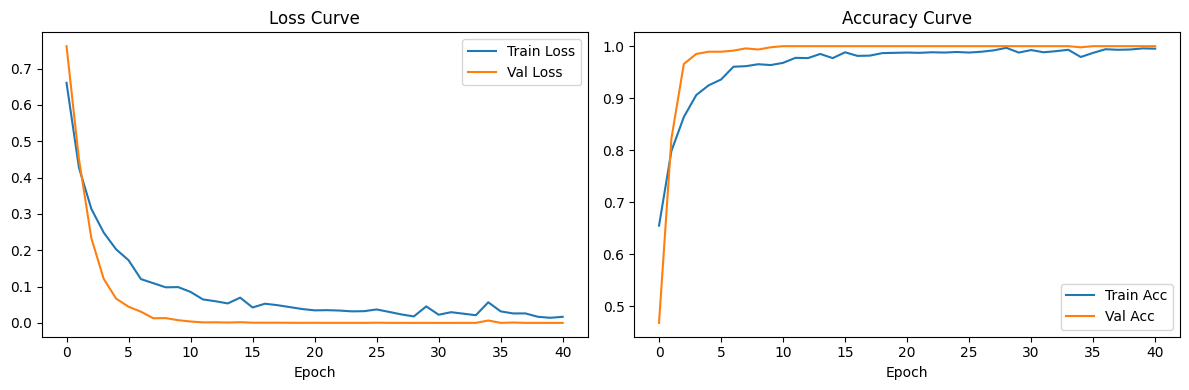

In [32]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
import matplotlib.pyplot as plt

In [34]:
# Cell 1 — Load:
X_train = np.load(data_dir / "X_tr_smote.npy")
y_train = np.load(data_dir / "y_tr_smote.npy")
X_val   = np.load(data_dir / "X_val.npy")
y_val   = np.load(data_dir / "y_val.npy")
X_test  = np.load(data_dir / "X_test.npy")
y_test  = np.load(data_dir / "y_test.npy")

# Cell 3 — model.fit:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # ← Yeh!
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.0570 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9877 - loss: 0.0350 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9899 - loss: 0.0289 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9888 - loss: 0.0289 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9872 - loss: 0.0340 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9909 - loss: 0.0276 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9941 - loss: 0.0160 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9936 - loss: 0.0206 - val_accuracy: 1.0000 - v

In [35]:
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score # Added precision_recall_curve

#threshold tuning samjate hai

y_prob_ann=model.predict(X_test).flatten() # taki 1d array dede prob ki

p,r,t=precision_recall_curve(y_test,y_prob_ann)

f1=2*(p[:-1]*r[:-1])/(p[:-1]+r[:-1]+1e-8)

# ab mujhe best threshold niklna konse index pr aayega f1

best_t=t[np.argmax(f1)] #threshold ki value jiske liye f1 maximum hoga

y_pred_ann=(y_prob_ann>=best_t).astype(int)

print(f"{best_t:.3f}") # Corrected f-string
print(classification_report(y_test,y_pred=y_pred_ann, target_names=["PASS(0)","FAIL(1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ann):.4f}") # Corrected y_proba_ann to y_prob_ann

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
0.363
              precision    recall  f1-score   support

     PASS(0)       0.94      0.96      0.95       293
     FAIL(1)       0.24      0.19      0.21        21

    accuracy                           0.90       314
   macro avg       0.59      0.57      0.58       314
weighted avg       0.90      0.90      0.90       314

ROC-AUC: 0.5726


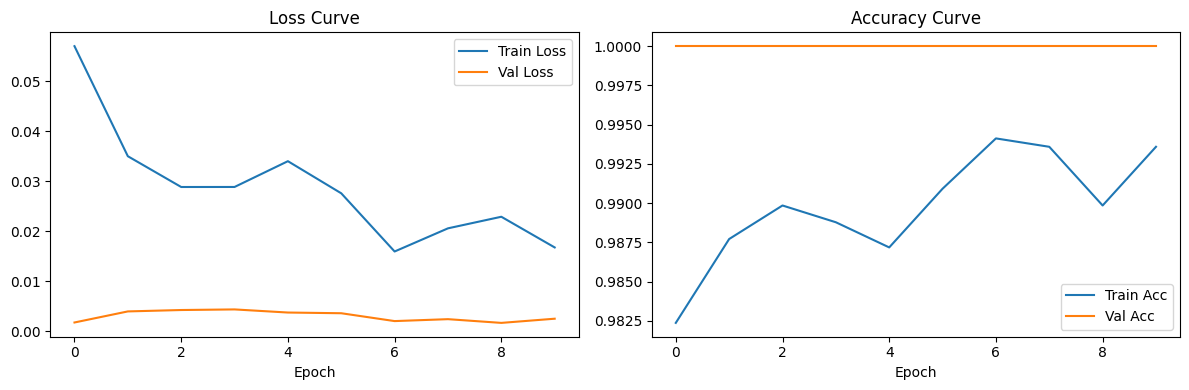

In [36]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


In [37]:
# lets apply lstm

In [38]:
data_dir = Path("..") / "data" / "processed"  

X_train = np.load(data_dir / "X_train.npy")
y_train = np.load(data_dir / "y_train.npy")
X_val   = np.load(data_dir / "X_val.npy")
y_val   = np.load(data_dir / "y_val.npy")
X_test  = np.load(data_dir / "X_test.npy")
y_test  = np.load(data_dir / "y_test.npy")

print(f"X_train shape : {X_train.shape}")
print(f"y_train dist  : PASS={sum(y_train==0)}, FAIL={sum(y_train==1)}")

X_train shape : (2340, 195)
y_train dist  : PASS=1170, FAIL=1170


In [39]:
X_train_lstm=X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],1
)

X_val_lstm=X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],1
)

X_test_lstm=X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],1)


print(f"X_train_lstm: {X_train_lstm.shape}")
print(f"X_val_lstm  : {X_val_lstm.shape}")
print(f"X_test_lstm : {X_test_lstm.shape}")


X_train_lstm: (2340, 195, 1)
X_val_lstm  : (251, 195, 1)
X_test_lstm : (314, 195, 1)


In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Bidirectional, Dropout, Dense, BatchNormalization

#create lstm model

tf.keras.backend.clear_session()

lstm_model=Sequential([
    Bidirectional(LSTM(64,return_sequences=True),input_shape=(X_train_lstm.shape[1],1)),
    Dropout(0.3),



    #lstm layer 2
    LSTM(32,return_sequences=False),
    Dropout(0.3),


    #Dense Layer
    Dense(32),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.2),


    #output
    Dense(1,activation='sigmoid')





])


lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 195, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 195, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,617 (217.25 KB)

 Trainable params: 55,553 (217.00 KB)

 Non-trainable params: 64 (256.00 B)

In [41]:
# INPUT
# (batch, 195, 1)
# ↓
# ┌─────────────────────────────┐
# │  Bidirectional LSTM (64)    │
# │                             │
# │  Forward  → → → → → →      │
# │  sensor1,2,3...195          │
# │                             │
# │  Backward ← ← ← ← ← ←      │
# │  sensor195...3,2,1          │
# │                             │
# │  Output = 64×2 = 128        │
# │  (forward + backward)       │
# │  Shape: (batch, 195, 128)   │
# └─────────────────────────────┘
# ↓
# Dropout(0.3)
# ↓
# ┌─────────────────────────────┐
# │  LSTM (32)                  │
# │                             │
# │  195 steps process karo     │
# │  Sirf last step ka          │
# │  output lo!                 │
# │  (return_sequences=False)   │
# │                             │
# │  Shape: (batch, 32)         │
# └─────────────────────────────┘
# ↓
# Dropout(0.3)
# ↓
# ┌─────────────────────────────┐
# │  Dense(32) + BN + ReLU      │
# │  Shape: (batch, 32)         │
# └─────────────────────────────┘
# ↓
# Dropout(0.2)
# ↓
# ┌─────────────────────────────┐
# │  Dense(1) + Sigmoid         │
# │  Shape: (batch, 1)          │
# │  0.0 to 1.0 probability     │
# └─────────────────────────────┘
# ↓
# OUTPUT
# PASS ya FAIL probability!

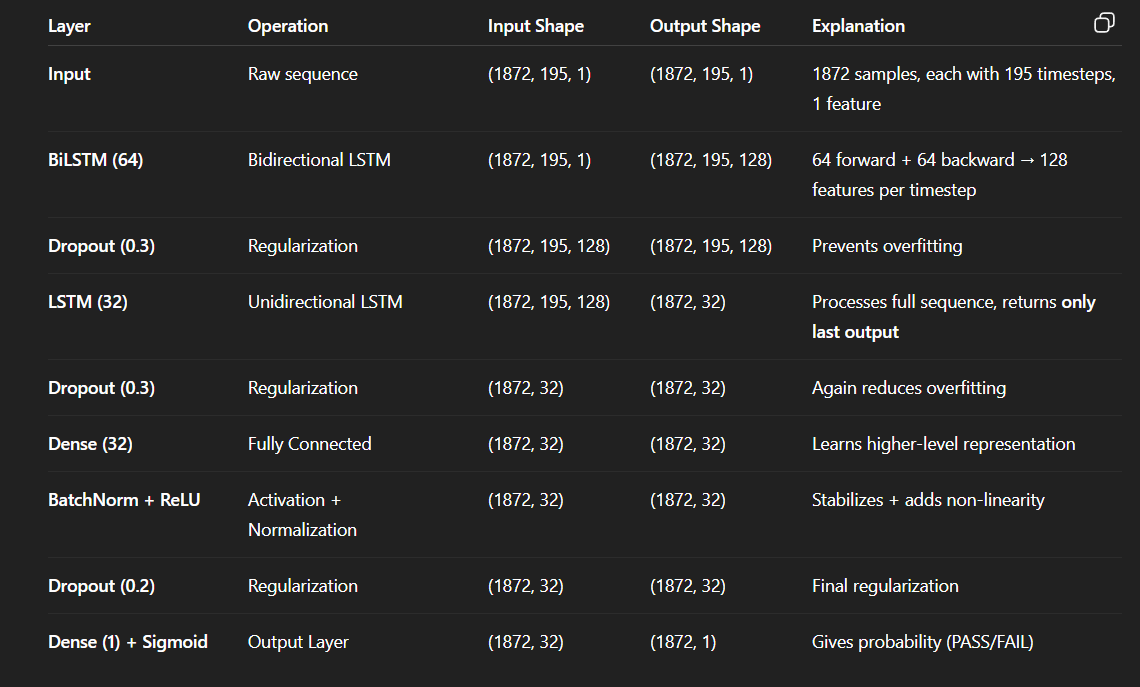

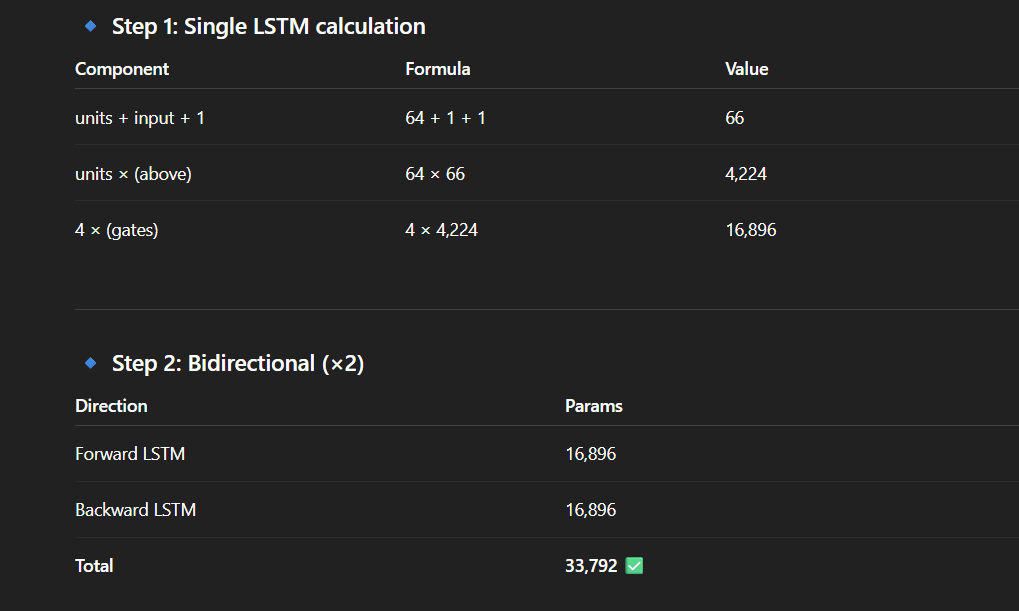

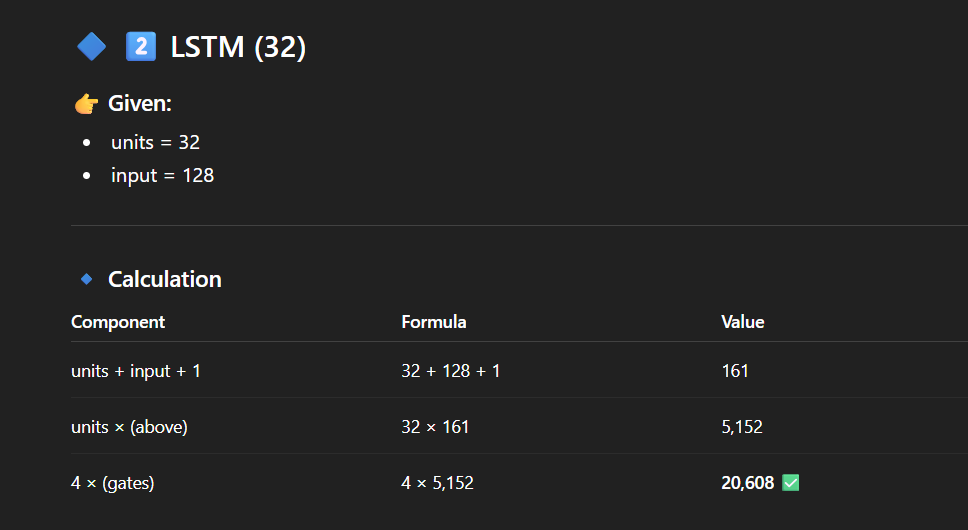

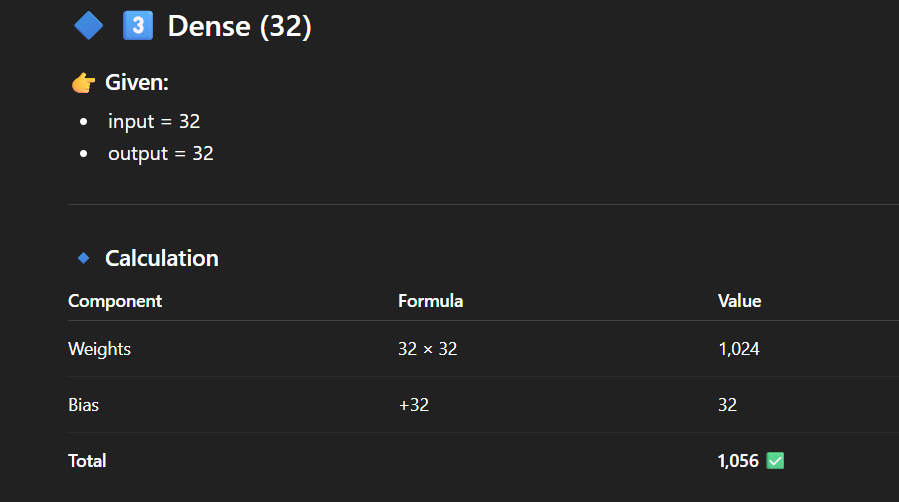


In [42]:
#compile +train

# Define class_weight for the LSTM model
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg/pos}
print(f"Class weight for LSTM: {class_weight}")

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]


)


callbacks_lstm=[
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    )
]

history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks_lstm,
    verbose=1
)


Class weight for LSTM: {0: 1.0, 1: np.float64(1.0)}
Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 167ms/step - accuracy: 0.5321 - auc: 0.5456 - loss: 0.7011 - recall: 0.4761 - val_accuracy: 0.1076 - val_auc: 0.4827 - val_loss: 0.7147 - val_recall: 0.9412 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 0.5863 - auc: 0.6120 - loss: 0.6676 - recall: 0.6368 - val_accuracy: 0.1594 - val_auc: 0.6053 - val_loss: 0.7169 - val_recall: 0.9412 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.6205 - auc: 0.6632 - loss: 0.6483 - recall: 0.6709 - val_accuracy: 0.7610 - val_auc: 0.4540 - val_loss: 0.6506 - val_recall: 0.2353 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.7222 - auc: 0.7906 - loss: 0.5525 - recall: 0.7051 - val_accuracy: 0.9044 - val_auc: 0.5124 - val_loss: 0.5607 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms

In [43]:
y_prob_lstm = lstm_model.predict(X_test_lstm).flatten()

p, r, t = precision_recall_curve(y_test, y_prob_lstm)
f1 = 2 * (p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-8)
best_t = t[np.argmax(f1)]
y_pred_lstm = (y_prob_lstm >= best_t).astype(int)

print(f"\nThreshold: {best_t:.3f}")
print(classification_report(y_test, y_pred_lstm, target_names=['PASS(0)', 'FAIL(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lstm):.4f}\n")

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step

Threshold: 0.948
              precision    recall  f1-score   support

     PASS(0)       0.94      0.96      0.95       293
     FAIL(1)       0.25      0.19      0.22        21

    accuracy                           0.91       314
   macro avg       0.60      0.57      0.58       314
weighted avg       0.90      0.91      0.90       314

ROC-AUC: 0.5209



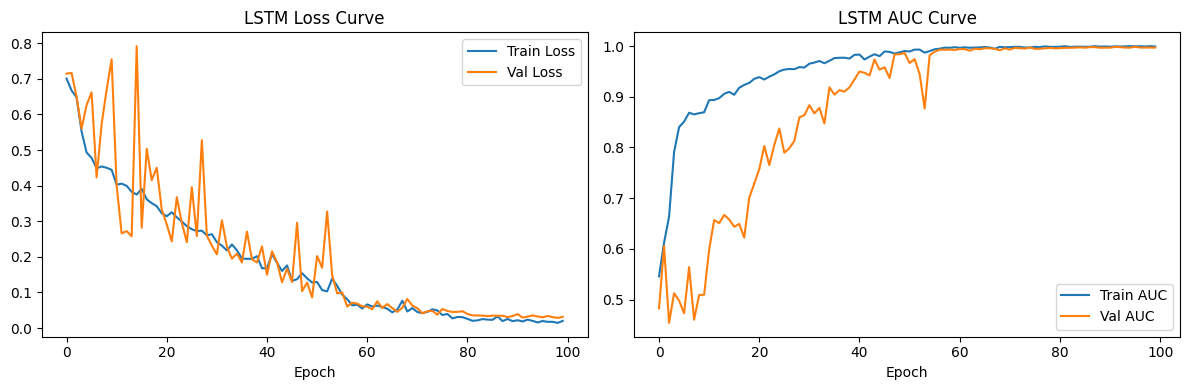

In [44]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['auc'], label='Train AUC')
plt.plot(history_lstm.history['val_auc'], label='Val AUC')
plt.title('LSTM AUC Curve')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

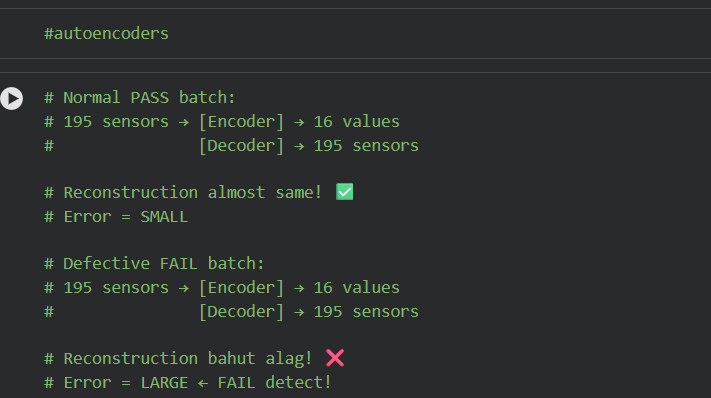

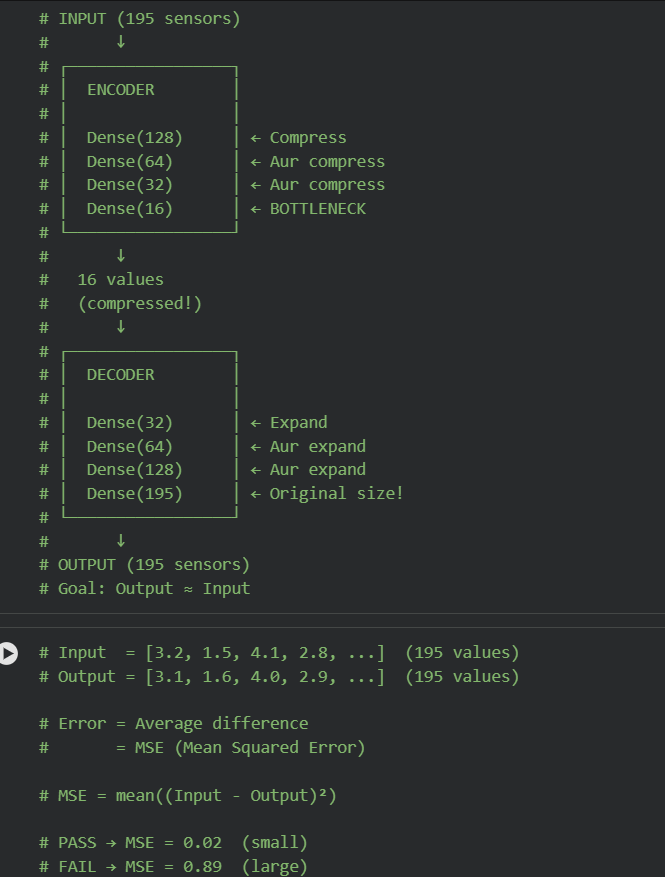

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (classification_report,
                             roc_auc_score,
                             precision_recall_curve)

In [49]:
#build autoencoder
input_dim=X_train.shape[1]


inputs=Input(shape=(input_dim,))

#Encoder
x=Dense(128,activation='relu')(inputs)
x=Dense(64,activation='relu')(x)
x=Dense(32,activation='relu')(x)
encoded=Dense(16,activation='relu')(x)


#Decoder
x=Dense(32,activation='relu')(encoded)
x=Dense(64,activation='relu')(x)
x=Dense(128,activation='relu')(x)
outputs=Dense(input_dim,activation='linear')(x)

In [48]:
# Autoencoder sirf PASS pe train hoga!
X_train_pass = X_train[y_train == 0]

print(f"Total train    : {X_train.shape[0]}")
print(f"PASS only      : {X_train_pass.shape[0]}")
print(f"Input features : {X_train_pass.shape[1]}")

Total train    : 2340
PASS only      : 1170
Input features : 195


In [50]:
autoencoder=Model(inputs,outputs)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 195)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 195)            │        25,155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,083 (281.57 KB)

 Trainable params: 72,083 (281.57 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
#compile+train

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)


callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]



history = autoencoder.fit(
    X_train_pass, X_train_pass,
    validation_data=(X_val[y_val == 0],
                     X_val[y_val == 0]),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)



Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9837 - val_loss: 1.0109
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9517 - val_loss: 0.9303
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8927 - val_loss: 0.8583
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8647 - val_loss: 0.8432
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8318 - val_loss: 0.7899
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7968 - val_loss: 0.7715
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7673 - val_loss: 0.7583
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7534 - val_loss: 0.7245
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7377 - val_loss: 0.7155
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7233 - val_loss: 0.7090
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7125 - val_loss: 0.6741
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

In [52]:
# Test data pe reconstruct karo
X_test_pred = autoencoder.predict(X_test)

# MSE har sample ke liye
mse = np.mean((X_test - X_test_pred) ** 2, axis=1)

print(f"PASS samples MSE: {mse[y_test==0].mean():.4f}")
print(f"FAIL samples MSE: {mse[y_test==1].mean():.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
PASS samples MSE: 0.6613
FAIL samples MSE: 0.6967


In [53]:
# Threshold = 95th percentile of PASS MSE
X_val_pred = autoencoder.predict(X_val)
mse_val    = np.mean((X_val - X_val_pred)**2, axis=1)
threshold  = np.percentile(mse_val[y_val == 0], 95)

print(f"Threshold: {threshold:.4f}")

# Predict karo
y_pred_ae = (mse >= threshold).astype(int)

print(classification_report(y_test, y_pred_ae,
      target_names=['PASS(0)', 'FAIL(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, mse):.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Threshold: 0.5722
              precision    recall  f1-score   support

     PASS(0)       0.92      0.50      0.65       293
     FAIL(1)       0.06      0.43      0.10        21

    accuracy                           0.50       314
   macro avg       0.49      0.47      0.38       314
weighted avg       0.87      0.50      0.61       314

ROC-AUC: 0.4838


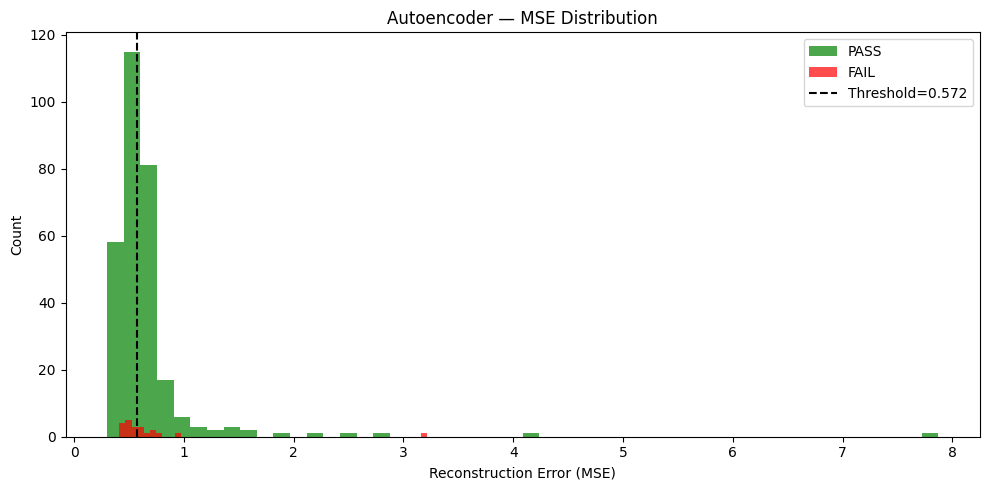

In [54]:
plt.figure(figsize=(10, 5))

plt.hist(mse[y_test==0], bins=50,
         alpha=0.7, color='green', label='PASS')
plt.hist(mse[y_test==1], bins=50,
         alpha=0.7, color='red',   label='FAIL')
plt.axvline(threshold, color='black',
            linestyle='--', label=f'Threshold={threshold:.3f}')

plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Autoencoder — MSE Distribution')
plt.legend()
plt.tight_layout()
plt.show() 

In [56]:
#corrected code 

In [58]:
#ann(made by ai)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path


data_dir = Path("..") / "data" / "processed"  

# Note: Assuming your X_train here is already SMOTEd based on your comment
X_train = np.load(data_dir / "X_train.npy")
y_train = np.load(data_dir / "y_train.npy")
X_val   = np.load(data_dir / "X_val.npy")
y_val   = np.load(data_dir / "y_val.npy")
X_test  = np.load(data_dir / "X_test.npy")
y_test  = np.load(data_dir / "y_test.npy")

print(f"X_train shape : {X_train.shape}")
print(f"y_train dist  : PASS={sum(y_train==0)}, FAIL={sum(y_train==1)}")



def build_ann(input_dim):
    model = Sequential([
        # Layer 1
        Dense(128, input_shape=(input_dim,)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        # Layer 2
        Dense(128),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        # Layer 3
        Dense(64),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.2),

        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    return model

model = build_ann(X_train.shape[1])
model.summary()



neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg/pos} 

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # ADDED AUC HERE
)



callbacks = [
    EarlyStopping(
        monitor='val_auc', 
        mode='max',
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=5
    )
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight,
    validation_data=(X_val, y_val), # Uses the untouched validation set!
    verbose=1
)



model.save('ann_model.keras') 
print("\nModel saved successfully as: ann_model.keras")

X_train shape : (2340, 195)
y_train dist  : PASS=1170, FAIL=1170


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,201 (200.00 KB)

 Trainable params: 50,561 (197.50 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6756 - auc: 0.7379 - loss: 0.6147 - val_accuracy: 0.9363 - val_auc: 0.8958 - val_loss: 0.2944 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8453 - auc: 0.9216 - loss: 0.3657 - val_accuracy: 0.9602 - val_auc: 0.9691 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9188 - auc: 0.9707 - loss: 0.2343 - val_accuracy: 0.9761 - val_auc: 0.9951 - val_loss: 0.1004 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9457 - auc: 0.9888 - loss: 0.1527 - val_accuracy: 0.9841 - val_auc: 0.9982 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9628 - auc: 0.9940 - loss: 0.1129 - val_accuracy: 0.9960 - val_auc: 1.0000 - val_loss: 0.0403 - learning_rate: 0.0010
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9671 - auc: 0.9951 

In [60]:
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score # Added precision_recall_curve

#threshold tuning samjate hai

y_prob_ann=model.predict(X_test).flatten() # taki 1d array dede prob ki

p,r,t=precision_recall_curve(y_test,y_prob_ann)

f1=2*(p[:-1]*r[:-1])/(p[:-1]+r[:-1]+1e-8)

# ab mujhe best threshold niklna konse index pr aayega f1

best_t=t[np.argmax(f1)] #threshold ki value jiske liye f1 maximum hoga

y_pred_ann=(y_prob_ann>=best_t).astype(int)

print(f"{best_t:.3f}") # Corrected f-string
print(classification_report(y_test,y_pred=y_pred_ann, target_names=["PASS(0)","FAIL(1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ann):.4f}") # Corrected y_proba_ann to y_prob_ann

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
0.007
              precision    recall  f1-score   support

     PASS(0)       0.97      0.73      0.83       293
     FAIL(1)       0.15      0.67      0.25        21

    accuracy                           0.73       314
   macro avg       0.56      0.70      0.54       314
weighted avg       0.91      0.73      0.80       314

ROC-AUC: 0.6649


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path


data_dir = Path("..") / "data" / "processed"  

X_train = np.load(data_dir / "X_train.npy")
y_train = np.load(data_dir / "y_train.npy")
X_val   = np.load(data_dir / "X_val.npy")
y_val   = np.load(data_dir / "y_val.npy")
X_test  = np.load(data_dir / "X_test.npy")
y_test  = np.load(data_dir / "y_test.npy")

print(f"X_train shape : {X_train.shape}")
print(f"y_train dist  : PASS={sum(y_train==0)}, FAIL={sum(y_train==1)}")



X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_lstm   = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test_lstm  = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print(f"\nX_train_lstm : {X_train_lstm.shape}")
print(f"X_val_lstm   : {X_val_lstm.shape}")
print(f"X_test_lstm  : {X_test_lstm.shape}\n")



tf.keras.backend.clear_session()

lstm_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=False), input_shape=(1, X_train.shape[1])),
    Dropout(0.3),

    # Dense Layer
    Dense(32),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.2),

    # Output Layer
    Dense(1, activation='sigmoid')
])

lstm_model.summary()


#
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg/pos}
print(f"Class weight for LSTM: {class_weight}")

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')
    ]
)



callbacks_lstm = [
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=5
    )
]

history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val), 
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks_lstm,
    verbose=1
)

lstm_model.save('lstm_model.keras')

X_train shape : (2340, 195)
y_train dist  : PASS=1170, FAIL=1170

X_train_lstm : (2340, 1, 195)
X_val_lstm   : (251, 1, 195)
X_test_lstm  : (314, 1, 195)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,409 (536.75 KB)

 Trainable params: 137,345 (536.50 KB)

 Non-trainable params: 64 (256.00 B)

Class weight for LSTM: {0: 1.0, 1: np.float64(1.0)}
Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7551 - auc: 0.8447 - loss: 0.5023 - recall: 0.8598 - val_accuracy: 0.8207 - val_auc: 0.9849 - val_loss: 0.5529 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9350 - auc: 0.9813 - loss: 0.2422 - recall: 0.9615 - val_accuracy: 0.9442 - val_auc: 1.0000 - val_loss: 0.3296 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9628 - auc: 0.9953 - loss: 0.1461 - recall: 0.9786 - val_accuracy: 0.9841 - val_auc: 1.0000 - val_loss: 0.1476 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9859 - auc: 0.9992 - loss: 0.0900 - recall: 0.9923 - val_accuracy: 0.9920 - val_auc: 1.0000 - val_loss: 0.0658 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 

In [62]:
y_prob_lstm = lstm_model.predict(X_test_lstm).flatten()

p, r, t = precision_recall_curve(y_test, y_prob_lstm)
f1 = 2 * (p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-8)
best_t = t[np.argmax(f1)]
y_pred_lstm = (y_prob_lstm >= best_t).astype(int)

print(f"\nThreshold: {best_t:.3f}")
print(classification_report(y_test, y_pred_lstm, target_names=['PASS(0)', 'FAIL(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lstm):.4f}\n")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

Threshold: 0.188
              precision    recall  f1-score   support

     PASS(0)       0.94      0.93      0.94       293
     FAIL(1)       0.19      0.24      0.21        21

    accuracy                           0.88       314
   macro avg       0.57      0.58      0.57       314
weighted avg       0.89      0.88      0.89       314

ROC-AUC: 0.6251



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, roc_auc_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


data_dir = Path("..") / "data" / "processed"  

X_train = np.load(data_dir / "X_train.npy") 
y_train = np.load(data_dir / "y_train.npy")
X_val   = np.load(data_dir / "X_val.npy")
y_val   = np.load(data_dir / "y_val.npy")
X_test  = np.load(data_dir / "X_test.npy")
y_test  = np.load(data_dir / "y_test.npy")


X_train_pass = X_train[y_train == 0]
X_val_pass   = X_val[y_val == 0] 

print(f"Total train    : {X_train.shape[0]}")
print(f"PASS only      : {X_train_pass.shape[0]}")
print(f"Input features : {X_train_pass.shape[1]}")



input_dim = X_train.shape[1]
inputs = Input(shape=(input_dim,))

# Encoder
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
encoded = Dense(16, activation='relu')(x) # Bottleneck

# Decoder
x = Dense(32, activation='relu')(encoded)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs, outputs)
autoencoder.summary()


autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Train the model to reconstruct ONLY normal data
history = autoencoder.fit(
    X_train_pass, X_train_pass, # Input = Output
    epochs=100,
    batch_size=32,
    validation_data=(X_val_pass, X_val_pass),
    callbacks=callbacks,
    verbose=1
)



print("\n--- Evaluation ---")
X_val_pred = autoencoder.predict(X_val)
mse_val    = np.mean((X_val - X_val_pred)**2, axis=1)
threshold  = np.percentile(mse_val[y_val == 0], 95)
print(f"Threshold (95th Percentile): {threshold:.4f}")

# Test set pe predict karo
X_test_pred = autoencoder.predict(X_test)
mse_test = np.mean((X_test - X_test_pred) ** 2, axis=1)

print(f"PASS samples Test MSE: {mse_test[y_test==0].mean():.4f}")
print(f"FAIL samples Test MSE: {mse_test[y_test==1].mean():.4f}")

# Classification Report and AUC
y_pred_ae = (mse_test >= threshold).astype(int)

print("\n" + classification_report(y_test, y_pred_ae, target_names=['PASS(0)', 'FAIL(1)']))
print(f"Autoencoder ROC-AUC: {roc_auc_score(y_test, mse_test):.4f}")

autoencoder.save('autoencoder_model.keras')

Total train    : 2340
PASS only      : 1170
Input features : 195


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 195)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 195)            │        25,155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,083 (281.57 KB)

 Trainable params: 72,083 (281.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9831 - val_loss: 1.0095
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9512 - val_loss: 0.9458
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8870 - val_loss: 0.8542
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8315 - val_loss: 0.8231
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8027 - val_loss: 0.7953
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7963 - val_loss: 0.7710
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7702 - val_loss: 0.7537
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7557 - val_loss: 0.7356
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7397 - val_loss: 0.7128
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7252 - val_loss: 0.6872
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7119 - val_loss: 0.6683
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.